# PHASE 2: HUẤN LUYỆN MÔ HÌNH NETWORK
## LightGBM: CPU | XGBoost: GPU

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
import xgboost as xgb
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

os.makedirs('Phase2_Network_Models', exist_ok=True)
os.makedirs('Phase2_Network_Data', exist_ok=True)

print("=" * 60)
print("PHASE 2: HUẤN LUYỆN MÔ HÌNH NETWORK")
print("=" * 60)

PHASE 2: HUẤN LUYỆN MÔ HÌNH NETWORK


## BƯỚC 1: LOAD DỮ LIỆU

In [2]:
print("\nBƯỚC 1: LOAD DỮ LIỆU")
print("-" * 40)

X_train = pd.read_csv('Phase1_Network_Data/X_train_processed.csv')
X_test = pd.read_csv('Phase1_Network_Data/X_test_processed.csv')
y_train = pd.read_csv('Phase1_Network_Data/y_train_processed.csv').iloc[:, 0]
y_test = pd.read_csv('Phase1_Network_Data/y_test_processed.csv').iloc[:, 0]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


BƯỚC 1: LOAD DỮ LIỆU
----------------------------------------
Train: (82332, 42), Test: (175341, 42)


## BƯỚC 2: THIẾT LẬP MODELS

In [3]:
print("\nBƯỚC 2: THIẾT LẬP MODELS")
print("-" * 40)

models = {}

models['Decision Tree'] = DecisionTreeClassifier(
    max_depth=20, min_samples_split=10, random_state=42, class_weight='balanced'
)

models['Random Forest'] = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=42, n_jobs=-1, class_weight='balanced'
)

models['LightGBM'] = lgb.LGBMClassifier(
    n_estimators=100, max_depth=20, learning_rate=0.1,
    num_leaves=31, random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced'
)

models['XGBoost'] = xgb.XGBClassifier(
    n_estimators=100, max_depth=20, learning_rate=0.1,
    random_state=42, tree_method='hist', device='cuda', scale_pos_weight=2.0
)

print(f"Models: {list(models.keys())}")


BƯỚC 2: THIẾT LẬP MODELS
----------------------------------------
Models: ['Decision Tree', 'Random Forest', 'LightGBM', 'XGBoost']


## BƯỚC 3: TRAINING

In [4]:
print("\nBƯỚC 3: TRAINING")
print("-" * 40)

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")
    
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[name] = {
        'model': model,
        'train_time': train_time,
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1_score': f1,
        'predictions': y_pred
    }
    
    print(f"Time: {train_time:.2f}s")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")


BƯỚC 3: TRAINING
----------------------------------------

Training Decision Tree...
Time: 0.79s
Accuracy: 0.8947
F1-Score: 0.8974

Training Random Forest...
Time: 1.60s
Accuracy: 0.9001
F1-Score: 0.9026

Training LightGBM...
Time: 0.47s
Accuracy: 0.8970
F1-Score: 0.8997

Training XGBoost...
Time: 3.22s
Accuracy: 0.9003
F1-Score: 0.9028


## BƯỚC 4: SO SÁNH MODELS

In [5]:
print("\nBƯỚC 4: SO SÁNH MODELS")
print("-" * 40)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()],
    'Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
    'Precision': [results[m]['test_precision'] for m in results.keys()],
    'Recall': [results[m]['test_recall'] for m in results.keys()],
    'F1-Score': [results[m]['test_f1_score'] for m in results.keys()]
})

print(comparison_df.to_string(index=False))
comparison_df.to_csv('Phase2_Network_Data/model_comparison.csv', index=False)

# Select best model
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_model = results[best_model_name]['model']
best_metrics = results[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"F1-Score: {best_metrics['test_f1_score']:.4f}")


BƯỚC 4: SO SÁNH MODELS
----------------------------------------
        Model  Train Time (s)  Accuracy  Precision   Recall  F1-Score
Decision Tree        0.790728  0.894719   0.913763 0.894719  0.897424
Random Forest        1.598742  0.900092   0.918792 0.900092  0.902650
     LightGBM        0.466298  0.897035   0.917058 0.897035  0.899738
      XGBoost        3.222382  0.900348   0.917880 0.900348  0.902834

Best Model: XGBoost
F1-Score: 0.9028


## VISUALIZATION: NETWORK MODEL PERFORMANCE

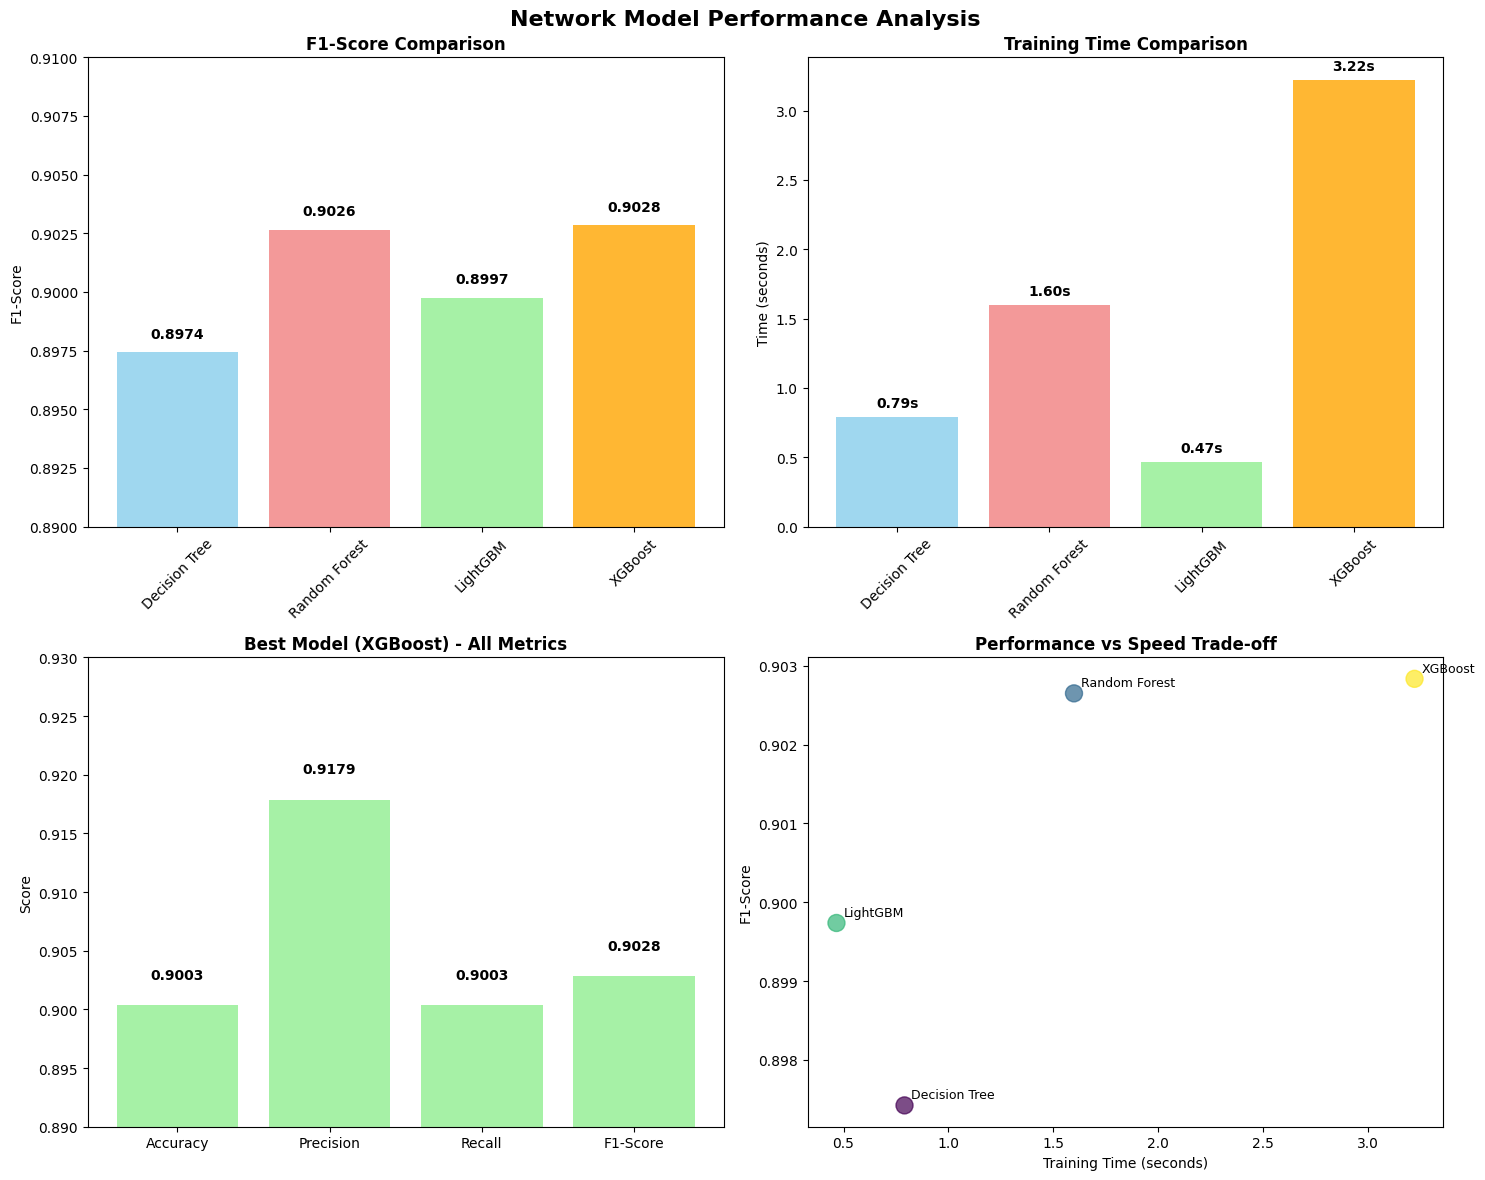


🏆 NETWORK BEST MODEL:
Model: XGBoost
F1-Score: 0.9028
Training Time: 3.22s


In [6]:
# Network model performance visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Network Model Performance Analysis', fontsize=16, fontweight='bold')

# 1. Model performance comparison
ax1 = axes[0, 0]
models_list = list(results.keys())
f1_scores = [results[m]['test_f1_score'] for m in models_list]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange']
bars = ax1.bar(models_list, f1_scores, color=colors, alpha=0.8)
ax1.set_title('F1-Score Comparison', fontweight='bold')
ax1.set_ylabel('F1-Score')
ax1.set_ylim(0.89, 0.91)
ax1.tick_params(axis='x', rotation=45)
for bar, score in zip(bars, f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005, 
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Training time comparison
ax2 = axes[0, 1]
train_times = [results[m]['train_time'] for m in models_list]
bars = ax2.bar(models_list, train_times, color=colors, alpha=0.8)
ax2.set_title('Training Time Comparison', fontweight='bold')
ax2.set_ylabel('Time (seconds)')
ax2.tick_params(axis='x', rotation=45)
for bar, time_val in zip(bars, train_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')

# 3. All metrics for best model
ax3 = axes[1, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
best_metrics_values = [
    results[best_model_name]['test_accuracy'],
    results[best_model_name]['test_precision'], 
    results[best_model_name]['test_recall'],
    results[best_model_name]['test_f1_score']
]
bars = ax3.bar(metrics, best_metrics_values, color='lightgreen', alpha=0.8)
ax3.set_title(f'Best Model ({best_model_name}) - All Metrics', fontweight='bold')
ax3.set_ylabel('Score')
ax3.set_ylim(0.89, 0.93)
for bar, score in zip(bars, best_metrics_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# 4. Performance vs Speed scatter
ax4 = axes[1, 1]
scatter = ax4.scatter(train_times, f1_scores, c=range(len(models_list)), 
                     s=150, alpha=0.7, cmap='viridis')
ax4.set_xlabel('Training Time (seconds)')
ax4.set_ylabel('F1-Score')
ax4.set_title('Performance vs Speed Trade-off', fontweight='bold')
for i, model in enumerate(models_list):
    ax4.annotate(model, (train_times[i], f1_scores[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig('Images/Phase2_Network_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🏆 NETWORK BEST MODEL:")
print(f"Model: {best_model_name}")
print(f"F1-Score: {best_metrics['test_f1_score']:.4f}")
print(f"Training Time: {best_metrics['train_time']:.2f}s")

## BƯỚC 5: LƯU BEST MODEL

In [7]:
print("\nBƯỚC 5: LƯU BEST MODEL")
print("-" * 40)

model_filename = 'network_' + best_model_name.lower().replace(" ", "_") + '_model.pkl'
with open(f'Phase2_Network_Models/{model_filename}', 'wb') as f:
    pickle.dump(best_model, f)

best_model_info = {
    'best_model_name': best_model_name,
    'test_accuracy': best_metrics['test_accuracy'],
    'test_precision': best_metrics['test_precision'],
    'test_recall': best_metrics['test_recall'],
    'test_f1_score': best_metrics['test_f1_score'],
    'train_time': best_metrics['train_time'],
    'model_filename': model_filename
}

with open('Phase2_Network_Models/best_model_info.pkl', 'wb') as f:
    pickle.dump(best_model_info, f)

print("✅ Đã lưu best model")


BƯỚC 5: LƯU BEST MODEL
----------------------------------------
✅ Đã lưu best model


## VISUALIZATION: NETWORK CONFUSION MATRIX

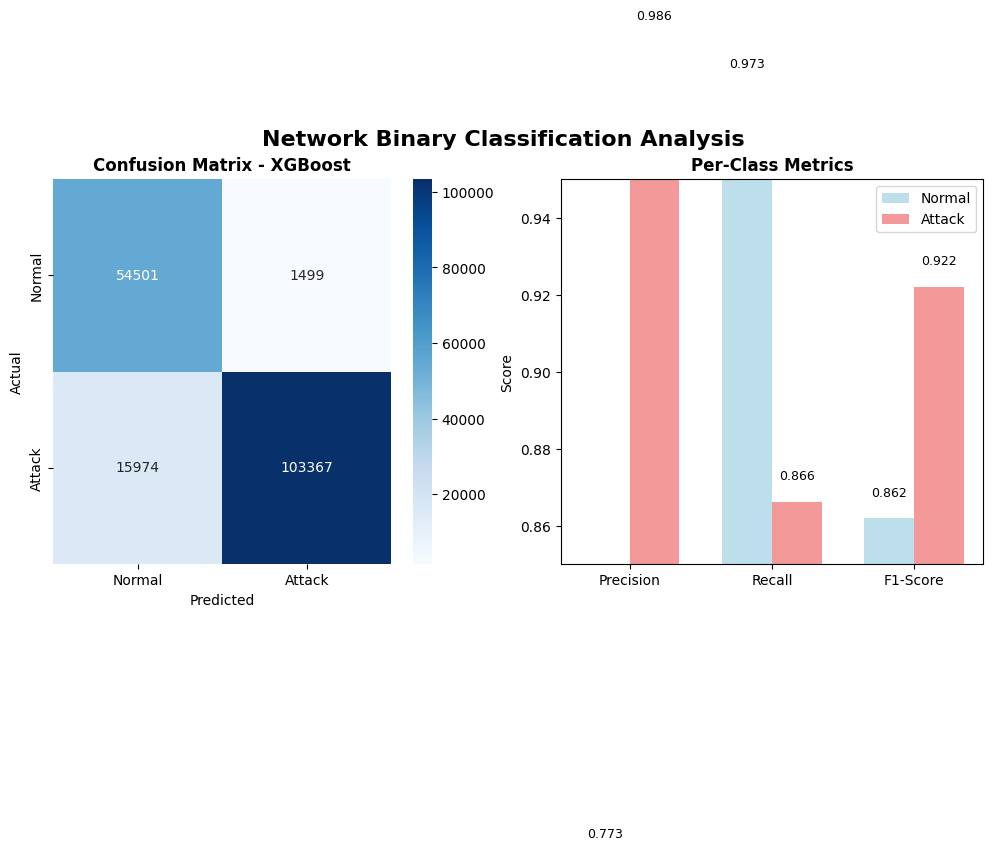

NETWORK CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.77      0.97      0.86     56000
      Attack       0.99      0.87      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341

✅ Đã lưu best model


In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Network confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Network Binary Classification Analysis', fontsize=16, fontweight='bold')

# 1. Confusion Matrix
ax1 = axes[0]
y_pred_network = results[best_model_name]['predictions']
cm_network = confusion_matrix(y_test, y_pred_network)

sns.heatmap(cm_network, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'], ax=ax1)
ax1.set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 2. Classification metrics breakdown
ax2 = axes[1]
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_network)

metrics_data = {
    'Normal': [precision[0], recall[0], f1[0]],
    'Attack': [precision[1], recall[1], f1[1]]
}
metrics_names = ['Precision', 'Recall', 'F1-Score']

x = np.arange(len(metrics_names))
width = 0.35
bars1 = ax2.bar(x - width/2, metrics_data['Normal'], width, label='Normal', alpha=0.8, color='lightblue')
bars2 = ax2.bar(x + width/2, metrics_data['Attack'], width, label='Attack', alpha=0.8, color='lightcoral')

ax2.set_title('Per-Class Metrics', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.legend()
ax2.set_ylim(0.85, 0.95)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('Images/Phase2_Network_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print classification report
print("NETWORK CLASSIFICATION REPORT:")
print("=" * 50)
print(classification_report(y_test, y_pred_network, target_names=['Normal', 'Attack']))

print("✅ Đã lưu best model")

## BƯỚC 6: TEST TRÊN RAW DATASET

In [9]:
print("\nBƯỚC 6: TEST TRÊN RAW DATASET")
print("-" * 40)

# Load raw test data
test_raw = pd.read_csv('Network/UNSW_NB15_testing-set.csv')
print(f"Raw test data: {test_raw.shape}")

# Drop unnecessary columns (same as Phase 1)
cols_to_drop = ['id', 'attack_cat', 'label']
cols_to_drop = [col for col in cols_to_drop if col in test_raw.columns]

# Separate features and target
X_test_raw = test_raw.drop(cols_to_drop, axis=1)
y_test_raw = test_raw['label']

# Load preprocessing artifacts
with open('Phase1_Network_Models/network_feature_encoders.pkl', 'rb') as f:
    feature_encoders = pickle.load(f)
with open('Phase1_Network_Models/network_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Apply encoding to categorical columns
X_test_encoded = X_test_raw.copy()
for col, encoder in feature_encoders.items():
    if col in X_test_encoded.columns:
        test_values = X_test_encoded[col].astype(str).values
        class_to_idx = {cls: idx for idx, cls in enumerate(encoder.classes_)}
        X_test_encoded[col] = np.array([class_to_idx.get(val, 0) for val in test_values])

# Apply scaling (CRITICAL FIX)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Features after encoding and scaling: {X_test_scaled.shape}")

# Predict with best model
y_pred_raw = best_model.predict(X_test_scaled)

# Evaluate
accuracy_raw = accuracy_score(y_test_raw, y_pred_raw)
precision_raw = precision_score(y_test_raw, y_pred_raw, average='weighted', zero_division=0)
recall_raw = recall_score(y_test_raw, y_pred_raw, average='weighted', zero_division=0)
f1_raw = f1_score(y_test_raw, y_pred_raw, average='weighted', zero_division=0)

print(f"\nKết quả test trên RAW dataset:")
print(f"Accuracy: {accuracy_raw:.4f}")
print(f"Precision: {precision_raw:.4f}")
print(f"Recall: {recall_raw:.4f}")
print(f"F1-Score: {f1_raw:.4f}")

print(f"\nSo sánh Processed vs Raw:")
print(f"  Processed F1: {best_metrics['test_f1_score']:.4f}")
print(f"  Raw F1: {f1_raw:.4f}")
print(f"  Difference: {abs(best_metrics['test_f1_score'] - f1_raw):.4f}")


BƯỚC 6: TEST TRÊN RAW DATASET
----------------------------------------
Raw test data: (175341, 45)
Features after encoding and scaling: (175341, 42)

Kết quả test trên RAW dataset:
Accuracy: 0.9003
Precision: 0.9179
Recall: 0.9003
F1-Score: 0.9028

So sánh Processed vs Raw:
  Processed F1: 0.9028
  Raw F1: 0.9028
  Difference: 0.0000


In [10]:
print("\n" + "=" * 60)
print("HOÀN THÀNH PHASE 2 NETWORK!")
print("=" * 60)
print(f"Best: {best_model_name}")
print(f"F1 (Processed): {best_metrics['test_f1_score']:.4f}")
print(f"F1 (Raw): {f1_raw:.4f}")


HOÀN THÀNH PHASE 2 NETWORK!
Best: XGBoost
F1 (Processed): 0.9028
F1 (Raw): 0.9028
